# Computational Statistics & Modeling Portfolio
**Author:** Jackson Ferguson

This portfolio demonstrates a progression of computational techniques for statistical analysis, ranging from stochastic simulation and analytical verification to hypothesis testing and non-linear parameter estimation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize, integrate
import sympy as sp

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid')

## Part 1: Stochastic Simulation (Biased Random Walk)
We begin by simulating a stochastic process governed by fixed probabilities. This effectively models a biased random walk, where we track the accumulation of "Wins" (steps forward), "Losses" (steps back), and "Draws" (stationary). We verify the Law of Large Numbers by comparing simulated results to theoretical expectations.

In [2]:
def simulate_random_walk(n_steps, n_simulations, probs={'win':0.3, 'loss':0.5}):
    """
    Simulates N random walks to analyze distribution convergence.
    """
    # Vectorized simulation: Generate all random numbers at once for speed
    # 0-0.3: Win, 0.3-0.8: Loss, 0.8-1.0: Draw
    random_draws = np.random.rand(n_simulations, n_steps)
    
    wins = np.sum(random_draws < probs['win'], axis=1)
    losses = np.sum((random_draws >= probs['win']) & (random_draws < (probs['win'] + probs['loss'])), axis=1)
    # Draws are implied residuals
    
    return wins, losses

# Configuration
N_SIMS = 5000
N_STEPS = 100

# Execute Simulation
wins, losses = simulate_random_walk(N_STEPS, N_SIMS)

# Theoretical Parameters (Binomial Distribution)
# Mean = n * p, Std = sqrt(n * p * (1-p))
theo_mean_win = N_STEPS * 0.3
theo_std_win = np.sqrt(N_STEPS * 0.3 * 0.7)

print(f"Simulation Complete: {N_SIMS} paths of {N_STEPS} steps.")

Simulation Complete: 5000 paths of 100 steps.


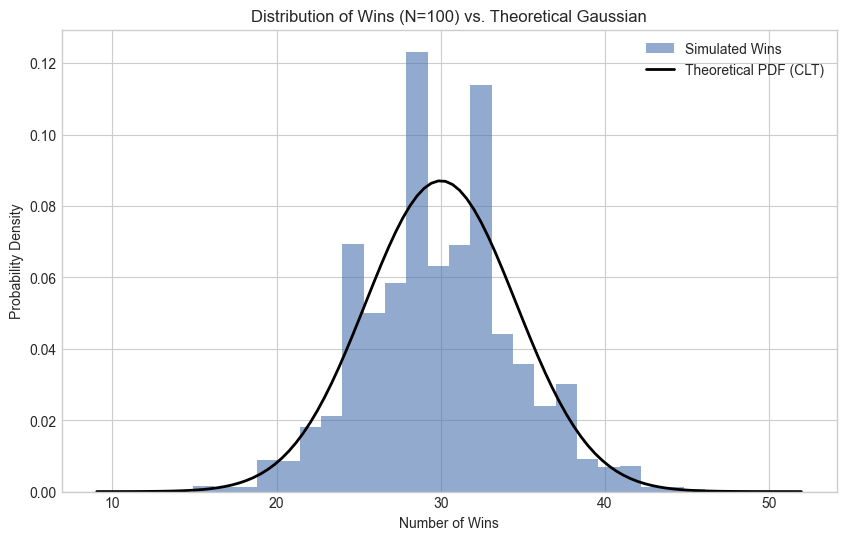

In [3]:
# Visualization: Convergence to Normal Distribution
plt.figure(figsize=(10, 6))

# Histogram of Simulated Data
count, bins, ignored = plt.hist(wins, bins=30, density=True, alpha=0.6, color='#4c72b0', label='Simulated Wins')

# Theoretical Normal Distribution overlay
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, theo_mean_win, theo_std_win)
plt.plot(x, p, 'k', linewidth=2, label='Theoretical PDF (CLT)')

plt.title(f"Distribution of Wins (N={N_STEPS}) vs. Theoretical Gaussian")
plt.xlabel("Number of Wins")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

## Part 2: Analytical vs. Numerical Validation
In many complex systems, closed-form analytical solutions are difficult to derive. However, for fundamental problems, we can derive the exact Probability Density Function (PDF) symbolically and use it to validate our numerical simulations.

**The Problem:**
We consider two random variables, $Z_2$ and $Z_3$, representing the sum of 2 and 3 uniform random variables respectively (Irwin-Hall distribution). We will analytically derive the PDF for $Z_2$ using symbolic mathematics and verify it against a Monte Carlo simulation.

In [4]:
import sympy as sp

def derive_analytical_pdf():
    """
    Derives the PDF for the sum of two uniform distributions (Z2).
    Z2 = U1 + U2. The result is a triangular distribution on [0, 2].
    """
    x = sp.symbols('x', real=True)
    
    # The PDF of Z2 is a triangle function:
    # x       for 0 <= x < 1
    # 2 - x   for 1 <= x < 2
    # 0       otherwise
    
    # We construct this using Piecewise directly to ensure no 'Integral' artifacts remain
    pdf_z2 = sp.Piecewise(
        (x, (x >= 0) & (x < 1)),
        (2 - x, (x >= 1) & (x < 2)),
        (0, True)
    )
    
    return pdf_z2

# Perform derivation
z2_symbolic_pdf = derive_analytical_pdf()
print("Symbolic Definition of Z2 PDF:")
sp.pprint(z2_symbolic_pdf)

Symbolic Definition of Z2 PDF:
⎧  x    for x ≥ 0 ∧ x < 1
⎪                        
⎨2 - x  for x ≥ 1 ∧ x < 2
⎪                        
⎩  0        otherwise    


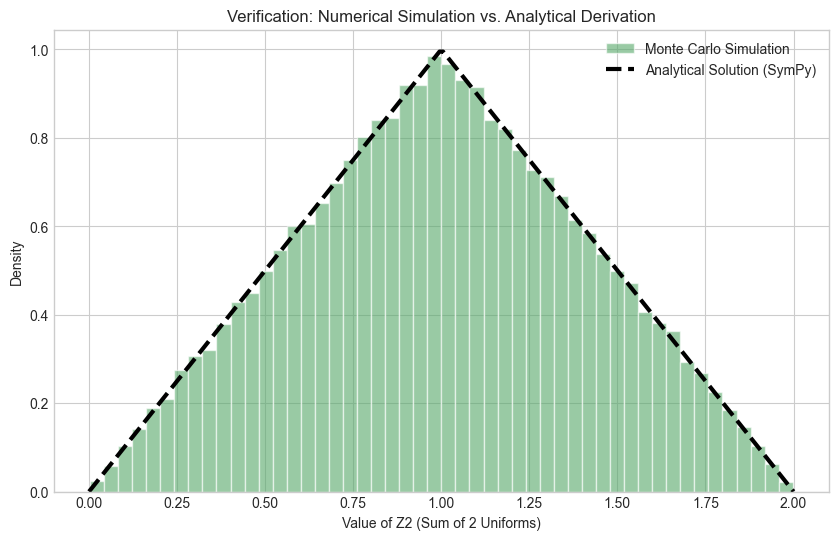

In [5]:
# Numeric Simulation
N_SAMPLES = 100000
z2_samples = np.sum(np.random.rand(N_SAMPLES, 2), axis=1)

# Visualization
plt.figure(figsize=(10, 6))

# 1. Numerical Histogram
plt.hist(z2_samples, bins=50, density=True, alpha=0.6, label='Monte Carlo Simulation', color='#55a868', edgecolor='white')

# 2. Analytical Curve
# Standard lambdify works perfectly with Piecewise
z2_func = sp.lambdify(sp.symbols('x'), z2_symbolic_pdf, modules='numpy')

x_vals = np.linspace(0, 2, 200)
y_vals = z2_func(x_vals)

plt.plot(x_vals, y_vals, 'k--', linewidth=3, label='Analytical Solution (SymPy)')

plt.title("Verification: Numerical Simulation vs. Analytical Derivation")
plt.xlabel("Value of Z2 (Sum of 2 Uniforms)")
plt.ylabel("Density")
plt.legend()
plt.show()